# House Price Prediction with XGBoost

1. L

In [1]:
## All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
import json
import os
from datetime import datetime
from pathlib import Path
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# RMSLE (Root Mean Squared Logarithmic Error) function
# NOTE: XGBoost has built-in RMSLE support via 'reg:squaredlogerror' objective
# and 'rmsle' eval_metric. This function is kept for post-training evaluation
# and comparison, but XGBoost will handle RMSLE automatically during training.
def rmsle(y_true, y_pred):
    """
    Calculate Root Mean Squared Logarithmic Error.
    
    RMSLE = sqrt(mean((log(1 + y_pred) - log(1 + y_true))^2))
    
    RMSLE is better for house prices because:
    - It penalizes underestimates more than overestimates
    - It's scale-independent (works well with skewed distributions)
    - It's less sensitive to outliers
    
    Note: XGBoost supports RMSLE natively via objective='reg:squaredlogerror'
    and eval_metric='rmsle', so this function is mainly for post-training evaluation.
    """
    # Ensure no negative values (add 1 to handle log)
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    
    # Calculate log of (1 + value) to handle zeros
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)
    
    # Calculate squared differences
    squared_diff = (log_pred - log_true) ** 2
    
    # Return root mean
    return np.sqrt(np.mean(squared_diff))

## 2. Load Dataset


In [2]:
# Load the dataset
df = pd.read_csv('houses_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (4853, 109)
Rows: 4,853
Columns: 109

First few rows:


,basic_info_bathrooms,basic_info_bedrooms,basic_info_description,basic_info_homeType_CONDO,basic_info_homeType_SINGLE_FAMILY,basic_info_house_age,basic_info_livingArea,basic_info_lotSize_sqft,basic_info_zipcode_94005,basic_info_zipcode_94014,...,property_details_standard_appliance_score,schools_elementary_school_distance,schools_elementary_school_rating,schools_high_school_distance,schools_high_school_rating,schools_middle_school_distance,schools_middle_school_rating,scores_bikeScore,scores_transitScore,scores_walkScore
0,2.0,2,Perched at the nexus of two of San Francisco's...,1,0,15.0,835.0,0.0,0,0,...,4.0,0.1,4.0,0.7,8.0,1.1,6.0,64.0,93.0,97.0
1,1.0,1,1 bedroom Below Market Rate (BMR) housing oppo...,1,0,15.0,613.0,0.0,0,0,...,5.0,0.4,5.0,1.2,8.0,1.6,6.0,62.0,100.0,99.0
2,1.0,2,"723 Taylor St #402, San Francisco, CA 94108 is...",1,0,15.0,757.0,0.0,0,0,...,0.0,0.4,5.0,1.2,8.0,1.6,6.0,62.0,100.0,99.0
3,1.0,1,$126k Reduction! This bright and modern upper-...,1,0,15.0,870.0,0.0,0,0,...,6.0,0.5,6.0,1.1,3.0,1.5,3.0,99.0,100.0,100.0
4,1.0,1,Chic and generous 1BR/1BA condo blocks from Ha...,1,0,16.0,920.0,0.0,0,0,...,4.0,0.5,6.0,1.1,3.0,1.4,3.0,99.0,100.0,99.0


## 3. Explore Dataset


In [3]:
# Check for missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("✅ No missing values!")

# Check data types
print(f"\nData types:")
print(df.dtypes.value_counts())


Missing values per column:
basic_info_description    25
dtype: int64

Data types:
int64      83
float64    25
object      1
Name: count, dtype: int64


Target variable: financial_lastSoldPrice

Statistics:
count    4.853000e+03
mean     1.769547e+06
std      1.919544e+06
min      5.000000e+02
25%      9.500000e+05
50%      1.370000e+06
75%      1.975000e+06
max      4.400000e+07
Name: financial_lastSoldPrice, dtype: float64


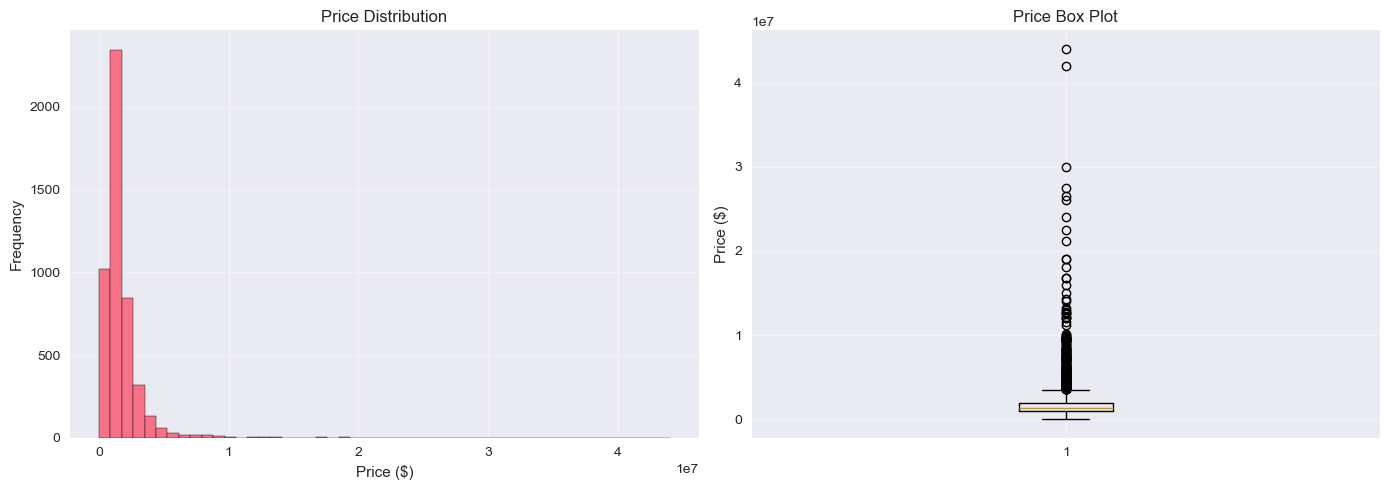

44000000.0


In [4]:
# Check target variable distribution
target_col = 'financial_lastSoldPrice'

if target_col in df.columns:
    print(f"Target variable: {target_col}")
    print(f"\nStatistics:")
    print(df[target_col].describe())
    
    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df[target_col], bins=50, edgecolor='black')
    axes[0].set_xlabel('Price ($)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Price Distribution')
    axes[0].grid(True, alpha=0.3)
    
    # Box plot
    axes[1].boxplot(df[target_col])
    axes[1].set_ylabel('Price ($)')
    axes[1].set_title('Price Box Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"❌ Target column '{target_col}' not found!")
    print(f"Available columns with 'price' or 'sold':")
    print([col for col in df.columns if 'price' in col.lower() or 'sold' in col.lower()])
print(max(df[target_col]))

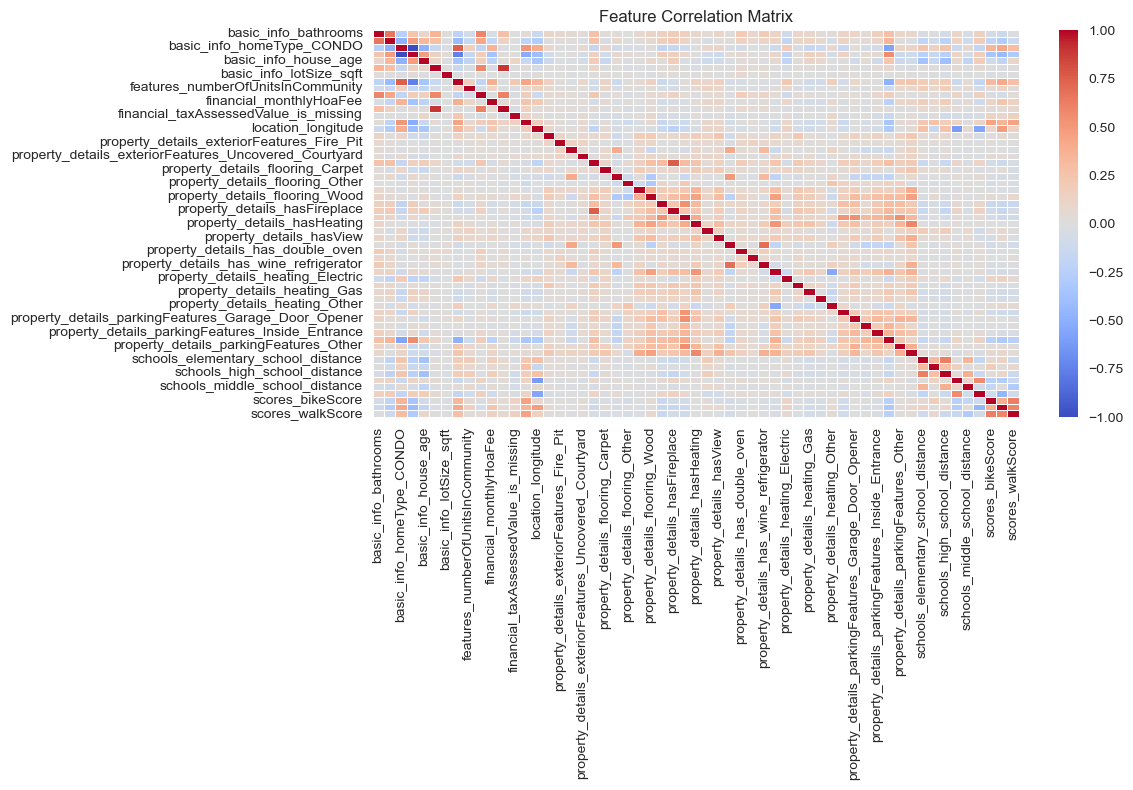

In [ ]:
# Plot the correlation matrix using seaborn
plt.figure(figsize=(12, 8))
# Drop the description column and any columns containing "zipcode"
drop_cols = ['basic_info_description'] + [col for col in df.columns if 'zipcode' in col.lower()] + [col for col in df.columns if 'neighborhood' in col.lower()]
corr = df.drop(columns=drop_cols, errors='ignore').corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 4. Split Features and Target


In [6]:
# Identify target and description columns
target_col = 'financial_lastSoldPrice'
description_col = 'basic_info_description'

# Extract target
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataset!")

y = df[target_col].copy()

# Extract description (for potential NLP features later)
descriptions = None
if description_col in df.columns:
    descriptions = df[description_col].copy()
    print(f"✅ Found description column: {description_col}")
    print(f"   Descriptions shape: {descriptions.shape}")
else:
    print(f"⚠️  Description column '{description_col}' not found")

# Extract features (everything except target and description)
columns_to_exclude = [target_col]
if description_col in df.columns:
    columns_to_exclude.append(description_col)

X = df.drop(columns=columns_to_exclude)

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist()[:20])
if len(X.columns) > 20:
    print(f"... and {len(X.columns) - 20} more")


✅ Found description column: basic_info_description
   Descriptions shape: (4853,)

Features shape: (4853, 107)
Target shape: (4853,)

Feature columns (107):
['basic_info_bathrooms', 'basic_info_bedrooms', 'basic_info_homeType_CONDO', 'basic_info_homeType_SINGLE_FAMILY', 'basic_info_house_age', 'basic_info_livingArea', 'basic_info_lotSize_sqft', 'basic_info_zipcode_94005', 'basic_info_zipcode_94014', 'basic_info_zipcode_94015', 'basic_info_zipcode_94102', 'basic_info_zipcode_94103', 'basic_info_zipcode_94104', 'basic_info_zipcode_94105', 'basic_info_zipcode_94107', 'basic_info_zipcode_94108', 'basic_info_zipcode_94109', 'basic_info_zipcode_94110', 'basic_info_zipcode_94111', 'basic_info_zipcode_94112']
... and 87 more


In [7]:
# Check feature data types
print("Feature data types:")
print(X.dtypes.value_counts())

# Identify numeric vs non-numeric features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Non-numeric features: {len(non_numeric_features)}")

if non_numeric_features:
    print(f"\nNon-numeric features: {non_numeric_features}")


Feature data types:
int64      83
float64    24
Name: count, dtype: int64

Numeric features: 107
Non-numeric features: 0


## 5. Prepare Features for Training


In [8]:
# Ensure all features are numeric (XGBoost requires numeric input)
# Convert any remaining non-numeric columns
if non_numeric_features:
    print(f"Converting {len(non_numeric_features)} non-numeric features...")
    for col in non_numeric_features:
        # Try to convert to numeric, or drop if can't
        try:
            X[col] = pd.to_numeric(X[col], errors='coerce')
        except:
            print(f"  Dropping column {col} (cannot convert to numeric)")
            X = X.drop(columns=[col])

# Fill any remaining NaN values with 0 (shouldn't be any after preprocessing)
if X.isnull().sum().sum() > 0:
    print(f"\nFilling {X.isnull().sum().sum()} NaN values with 0...")
    X = X.fillna(0)

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Feature columns: {len(X.columns)}")



Final feature matrix shape: (4853, 107)
Feature columns: 107


## 6. Train-Validate-Test Split


In [30]:
# Split into train (0.64), validate (0.16), and test (0.2) sets
# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

# Second split: split remaining 80% into train (64%) and validate (16%)
# train = 0.64 / 0.8 = 0.8 of temp, validate = 0.16 / 0.8 = 0.2 of temp
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,  # 0.2 of 0.8 = 0.16 of total
    random_state=42,
    shuffle=True
)

print("=" * 70)
print("DATA SPLIT SUMMARY")
print("=" * 70)
print(f"\nTraining set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Features:       {X_train.shape[1]}")

print(f"\nTraining target stats:")
print(y_train.describe())
print(f"\nValidation target stats:")
print(y_val.describe())
print(f"\nTest target stats:")
print(y_test.describe())
print("=" * 70)

# Check target variable
print("=" * 50)
print("TARGET VARIABLE CHECK:")
print("=" * 50)
print(f"y_train shape: {y_train.shape}")
print(f"y_train min: {y_train.min()}")
print(f"y_train max: {y_train.max()}")
print(f"y_train mean: {y_train.mean()}")
print(f"Zeros in y_train: {(y_train == 0).sum()}")
print(f"Negatives in y_train: {(y_train < 0).sum()}")
print(f"First 10 values: {y_train[:10]}")

# Check if X and y are aligned
print("\n" + "=" * 50)
print("ALIGNMENT CHECK:")
print("=" * 50)
print(f"X_train shape: {X_train.shape}")
print(f"Do shapes match? {X_train.shape[0] == y_train.shape[0]}")

# Check a simple baseline
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
print(f"\nBaseline (mean predictor) MAE: ${np.mean(np.abs(y_val - dummy_pred)):,.2f}")

DATA SPLIT SUMMARY

Training set:   3,105 samples (64.0%)
Validation set: 777 samples (16.0%)
Test set:       971 samples (20.0%)
Features:       107

Training target stats:
count    3.105000e+03
mean     1.737459e+06
std      1.776402e+06
min      5.000000e+02
25%      9.450000e+05
50%      1.365000e+06
75%      1.950000e+06
max      4.400000e+07
Name: financial_lastSoldPrice, dtype: float64

Validation target stats:
count    7.770000e+02
mean     1.801780e+06
std      2.011574e+06
min      1.400000e+04
25%      9.500000e+05
50%      1.380000e+06
75%      2.100000e+06
max      4.200000e+07
Name: financial_lastSoldPrice, dtype: float64

Test target stats:
count    9.710000e+02
mean     1.846363e+06
std      2.255157e+06
min      1.092340e+05
25%      9.500000e+05
50%      1.370000e+06
75%      1.918750e+06
max      3.000000e+07
Name: financial_lastSoldPrice, dtype: float64
TARGET VARIABLE CHECK:
y_train shape: (3105,)
y_train min: 500.0
y_train max: 44000000.0
y_train mean: 1737459.444

## 7. Train XGBoost Model


In [ ]:
## 7.5. Train Model with Hyperparameter Tracking

def train_and_track_model(hyperparams, run_id=None, save_graphs=True):
    """
    Train an XGBoost model with given hyperparameters and track results.
    
    Parameters:
    -----------
    hyperparams : dict
        Dictionary of hyperparameters for XGBoost
        Default values (if not specified):
        {
            'n_estimators': 1000,
            'max_depth': 3,
            'min_child_weight': 5,
            'reg_lambda': 5,
            'gamma': 0.1,
            'learning_rate': 0.01,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'eval_metric': 'rmsle'
        }
    run_id : str, optional
        Custom identifier for this run. If None, auto-generated.
    save_graphs : bool
        Whether to save prediction and residual graphs
        
    Returns:
    --------
    dict : Dictionary containing model, predictions, metrics, and result info
    """
    print("=" * 70)
    print("TRAINING MODEL WITH HYPERPARAMETERS")
    print("=" * 70)
    print(f"\nHyperparameters:")
    for key, value in hyperparams.items():
        print(f"  - {key}: {value}")
    
    # Initialize XGBoost regressor with hyperparameters
    xgb_model = xgb.XGBRegressor(
        objective=hyperparams.get('objective', 'reg:squaredlogerror'),  # Optimize for RMSLE
        
        # Reduced complexity
        max_depth=hyperparams.get('max_depth', 3),
        min_child_weight=hyperparams.get('min_child_weight', 5),
        
        # Regularization
        reg_lambda=hyperparams.get('reg_lambda', 5),  # L2 regularization
        gamma=hyperparams.get('gamma', 0.1),  # Minimum loss reduction for splits
        
        # Learning settings
        learning_rate=hyperparams.get('learning_rate', 0.01),
        n_estimators=hyperparams.get('n_estimators', 1000),
        subsample=hyperparams.get('subsample', 0.8),
        colsample_bytree=hyperparams.get('colsample_bytree', 0.8),
        
        random_state=hyperparams.get('random_state', 42),
        n_jobs=-1,
        early_stopping_rounds=hyperparams.get('early_stopping_rounds', 50),
        eval_metric=hyperparams.get('eval_metric', 'rmsle')
    )
    
    # Train the model
    print("\nTraining XGBoost model...")
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100
    )
    
    print("\n✅ Model training complete!")
    
    # Make predictions
    y_train_pred = xgb_model.predict(X_train)
    y_val_pred = xgb_model.predict(X_val)
    y_test_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_rmsle = rmsle(y_train, y_train_pred)
    val_rmsle = rmsle(y_val, y_val_pred)
    test_rmsle = rmsle(y_test, y_test_pred)
    
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Prepare metrics dictionary
    metrics = {
        'train_mae': float(train_mae),
        'train_rmse': float(train_rmse),
        'train_rmsle': float(train_rmsle),
        'train_r2': float(train_r2),
        'val_mae': float(val_mae),
        'val_rmse': float(val_rmse),
        'val_rmsle': float(val_rmsle),
        'val_r2': float(val_r2),
        'test_mae': float(test_mae),
        'test_rmse': float(test_rmse),
        'test_rmsle': float(test_rmsle),
        'test_r2': float(test_r2)
    }
    
    # Print metrics
    print("\n" + "=" * 70)
    print("MODEL PERFORMANCE METRICS")
    print("=" * 70)
    print(f"\nTraining Set:")
    print(f"  MAE:   ${train_mae:,.2f}")
    print(f"  RMSE:  ${train_rmse:,.2f}")
    print(f"  RMSLE: {train_rmsle:.6f}")
    print(f"  R²:    {train_r2:.4f}")
    print(f"\nValidation Set:")
    print(f"  MAE:   ${val_mae:,.2f}")
    print(f"  RMSE:  ${val_rmse:,.2f}")
    print(f"  RMSLE: {val_rmsle:.6f}")
    print(f"  R²:    {val_r2:.4f}")
    print(f"\nTest Set:")
    print(f"  MAE:   ${test_mae:,.2f}")
    print(f"  RMSE:  ${test_rmse:,.2f}")
    print(f"  RMSLE: {test_rmsle:.6f}")
    print(f"  R²:    {test_r2:.4f}")
    print("=" * 70)
    
    # Save graphs if requested
    graph_paths = {}
    if save_graphs:
        graph_paths = tracker.save_graphs(
            run_id or datetime.now().strftime('%Y%m%d_%H%M%S'),
            y_train, y_train_pred, y_val, y_val_pred, y_test, y_test_pred,
            train_rmsle, val_rmsle, test_rmsle, train_r2, val_r2, test_r2
        )
    
    # Add result to tracker
    result, is_best = tracker.add_result(hyperparams, xgb_model, metrics, run_id)
    
    # Update result with graph paths
    if graph_paths:
        result['graph_paths'] = graph_paths
        # Update the saved results file
        for i, r in enumerate(tracker.results):
            if r['run_id'] == result['run_id']:
                tracker.results[i] = result
        with open(tracker.results_file, 'w') as f:
            json.dump(tracker.results, f, indent=2)
    
    return {
        'model': xgb_model,
        'predictions': {
            'train': y_train_pred,
            'val': y_val_pred,
            'test': y_test_pred
        },
        'metrics': metrics,
        'result': result,
        'is_best': is_best
    }


In [ ]:
# Initialize XGBoost regressor with conservative hyperparameters
# Using 'reg:squaredlogerror' objective optimizes for RMSLE automatically
xgb_model = xgb.XGBRegressor(
    objective='reg:squaredlogerror',  # Optimizes for RMSLE - no need for custom function!
    
    # REDUCE complexity
    max_depth=3,              # Down from 4
    min_child_weight=5,       # Forces more samples per leaf
    
    # ADD regularization  
    reg_lambda=5,             # L2 regularization (lambda)
    gamma=0.1,                # Minimum loss reduction for splits
    
    # Learning settings
    learning_rate=0.01,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8,
    
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmsle'  # RMSLE is automatically used with reg:squaredlogerror, but explicit is clearer
)

print("Training XGBoost model...")
print(f"Parameters:")
print(f"  - objective: {xgb_model.objective}")
print(f"  - n_estimators: {xgb_model.n_estimators}")
print(f"  - max_depth: {xgb_model.max_depth}")
print(f"  - min_child_weight: {xgb_model.min_child_weight}")
print(f"  - reg_lambda: {xgb_model.reg_lambda}")
print(f"  - gamma: {xgb_model.gamma}")
print(f"  - learning_rate: {xgb_model.learning_rate}")
print(f"  - subsample: {xgb_model.subsample}")
print(f"  - colsample_bytree: {xgb_model.colsample_bytree}")
print(f"  - eval_metric: rmsle (automatically used with reg:squaredlogerror)")

# Train the model
# Use validation set for early stopping (not test set!)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print("\n✅ Model training complete!")


Training XGBoost model...
Parameters:
  - n_estimators: 1000
  - max_depth: 4
  - learning_rate: 0.01
  - subsample: 0.8
  - colsample_bytree: 0.8
[0]	validation_0-rmsle:0.72795	validation_1-rmsle:0.69440
[100]	validation_0-rmsle:0.51856	validation_1-rmsle:0.46651
[200]	validation_0-rmsle:0.45367	validation_1-rmsle:0.39543
[300]	validation_0-rmsle:0.42760	validation_1-rmsle:0.36604
[400]	validation_0-rmsle:0.41335	validation_1-rmsle:0.34998
[500]	validation_0-rmsle:0.40366	validation_1-rmsle:0.34019
[600]	validation_0-rmsle:0.39702	validation_1-rmsle:0.33418
[700]	validation_0-rmsle:0.39167	validation_1-rmsle:0.33023
[800]	validation_0-rmsle:0.38710	validation_1-rmsle:0.32748
[900]	validation_0-rmsle:0.38209	validation_1-rmsle:0.32513
[999]	validation_0-rmsle:0.37731	validation_1-rmsle:0.32287

✅ Model training complete!


## 8. Evaluate Model


In [32]:
# Make predictions on all three sets
y_train_pred = xgb_model.predict(X_train)
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

# Calculate metrics for all three sets
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_rmsle = rmsle(y_train, y_train_pred)
val_rmsle = rmsle(y_val, y_val_pred)
test_rmsle = rmsle(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print metrics
print("=" * 70)
print("MODEL PERFORMANCE METRICS")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  MAE:   ${train_mae:,.2f}")
print(f"  RMSE:  ${train_rmse:,.2f}")
print(f"  RMSLE: {train_rmsle:.6f}")
print(f"  R²:    {train_r2:.4f}")
print(f"\nValidation Set:")
print(f"  MAE:   ${val_mae:,.2f}")
print(f"  RMSE:  ${val_rmse:,.2f}")
print(f"  RMSLE: {val_rmsle:.6f}")
print(f"  R²:    {val_r2:.4f}")
print(f"\nTest Set:")
print(f"  MAE:   ${test_mae:,.2f}")
print(f"  RMSE:  ${test_rmse:,.2f}")
print(f"  RMSLE: {test_rmsle:.6f}")
print(f"  R²:    {test_r2:.4f}")
print("=" * 70)
print("\nNote: RMSLE (Root Mean Squared Logarithmic Error) is the primary metric.")
print("      Lower RMSLE is better. RMSLE penalizes underestimates more than overestimates.")
print("      Model was trained with early stopping on validation set.")
print("=" * 70)


MODEL PERFORMANCE METRICS

Training Set:
  MAE:   $241,827.83
  RMSE:  $395,323.99
  RMSLE: 0.377314
  R²:    0.9505

Validation Set:
  MAE:   $354,697.62
  RMSE:  $1,165,289.51
  RMSLE: 0.322865
  R²:    0.6640

Test Set:
  MAE:   $366,003.46
  RMSE:  $973,950.58
  RMSLE: 0.268043
  R²:    0.8133

Note: RMSLE (Root Mean Squared Logarithmic Error) is the primary metric.
      Lower RMSLE is better. RMSLE penalizes underestimates more than overestimates.
      Model was trained with early stopping on validation set.


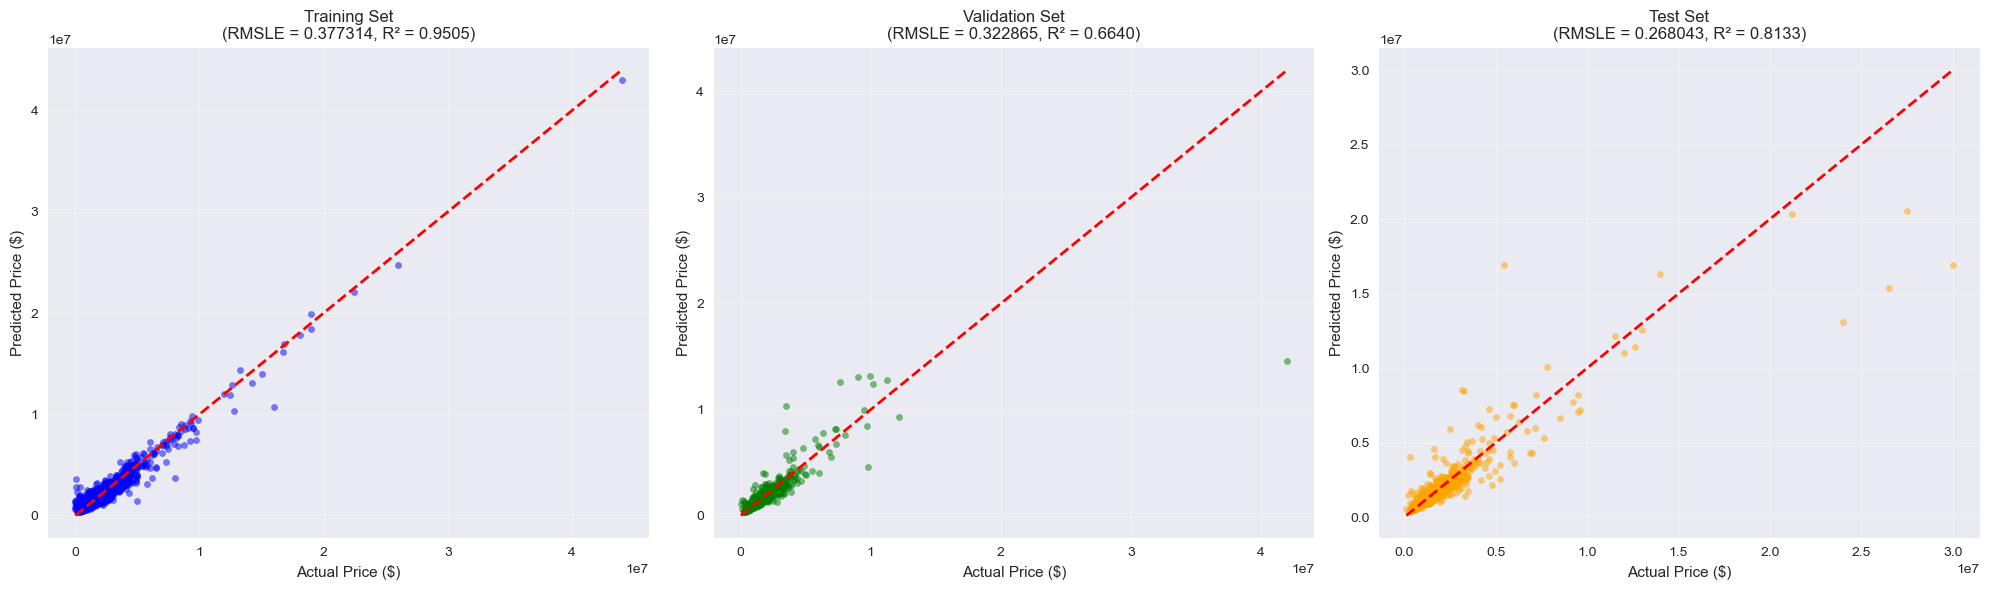

In [33]:
# Visualize predictions vs actual for all three sets
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=20, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Training Set\n(RMSLE = {train_rmsle:.6f}, R² = {train_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=20, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Validation Set\n(RMSLE = {val_rmsle:.6f}, R² = {val_r2:.4f})')
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Price ($)')
axes[2].set_ylabel('Predicted Price ($)')
axes[2].set_title(f'Test Set\n(RMSLE = {test_rmsle:.6f}, R² = {test_r2:.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


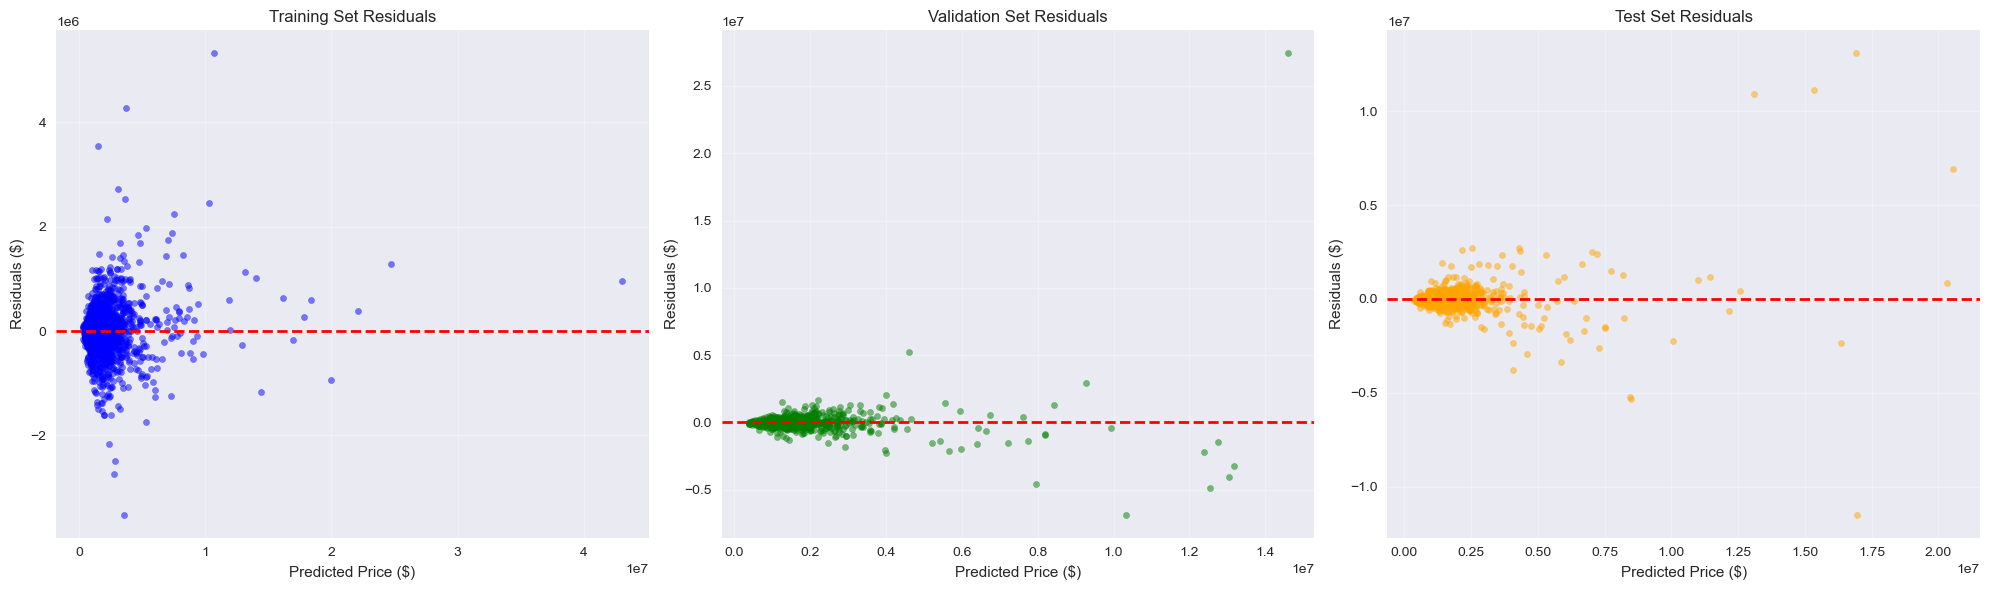

In [34]:
# Plot residuals for all three sets
train_residuals = y_train - y_train_pred
val_residuals = y_val - y_val_pred
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Training residuals
axes[0].scatter(y_train_pred, train_residuals, alpha=0.5, s=20, color='blue')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Training Set Residuals')
axes[0].grid(True, alpha=0.3)

# Validation residuals
axes[1].scatter(y_val_pred, val_residuals, alpha=0.5, s=20, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Validation Set Residuals')
axes[1].grid(True, alpha=0.3)

# Test residuals
axes[2].scatter(y_test_pred, test_residuals, alpha=0.5, s=20, color='orange')
axes[2].axhline(y=0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Predicted Price ($)')
axes[2].set_ylabel('Residuals ($)')
axes[2].set_title('Test Set Residuals')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Feature Importance


Top 20 Most Important Features:
basic_info_livingArea                             : 0.142870
financial_taxAssessedValue                        : 0.123834
schools_high_school_rating                        : 0.046422
location_latitude                                 : 0.035754
location_neighborhood_Pacific_Heights             : 0.030663
basic_info_bathrooms                              : 0.030656
basic_info_lotSize_sqft                           : 0.027413
basic_info_zipcode_94107                          : 0.019339
schools_elementary_school_distance                : 0.017454
property_details_parkingFeatures_On_Site_Single_Family_Only: 0.016425
property_details_hasSpa                           : 0.015540
basic_info_bedrooms                               : 0.015034
basic_info_zipcode_94115                          : 0.014901
property_details_parkingFeatures_Other            : 0.013875
property_details_hasHeating                       : 0.012845
basic_info_zipcode_94116                    

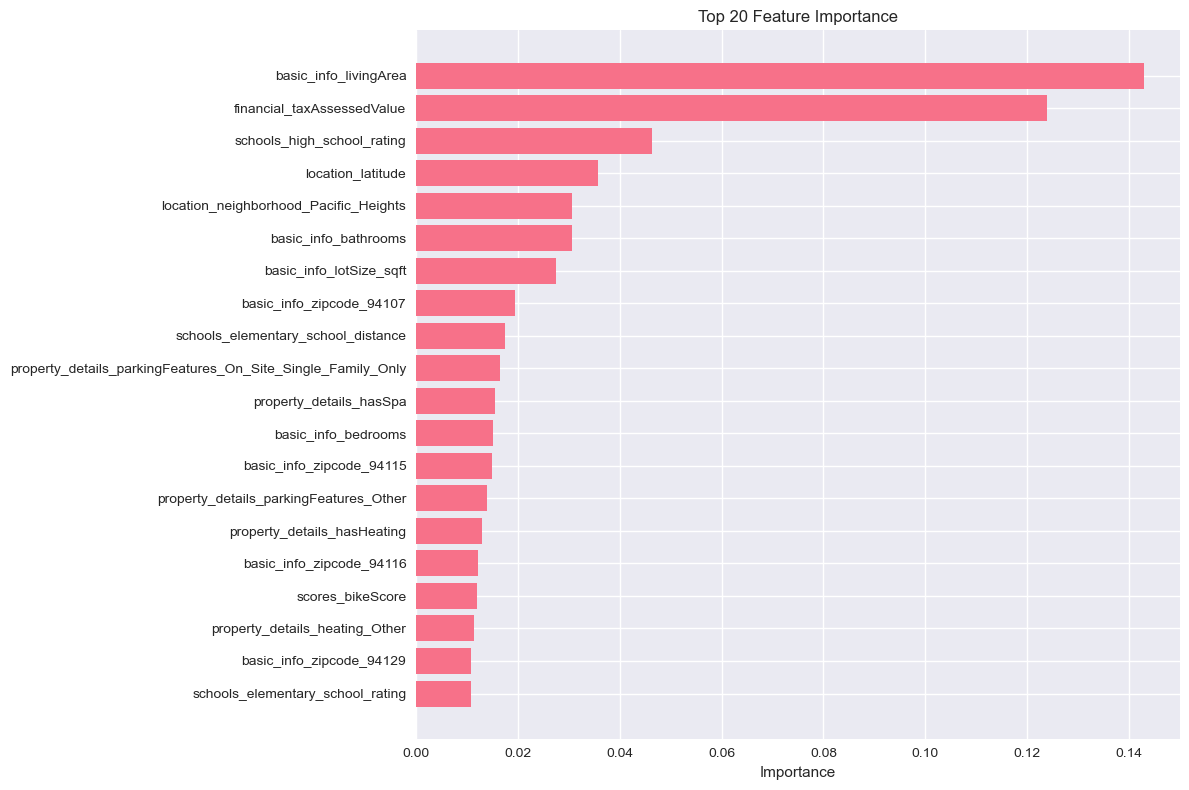

In [14]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print("=" * 70)
for i, row in feature_importance.head(20).iterrows():
    print(f"{row['feature']:50s}: {row['importance']:.6f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
top_n = 20
top_features = feature_importance.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 10. Save Model


## 11. Hyperparameter Search

Use the `train_and_track_model()` function to run hyperparameter searches. All results are automatically saved and tracked.


## 11.5. Grid Search Hyperparameter Optimization

Use GridSearchCV to systematically search through hyperparameter combinations. Results will be automatically tracked.


In [ ]:
# Grid Search Hyperparameter Optimization
# Note: Using validation set for final evaluation after grid search

print("=" * 70)
print("GRID SEARCH HYPERPARAMETER OPTIMIZATION")
print("=" * 70)

# Define parameter grid
# Note: 'lambda' in XGBoost is 'reg_lambda'
param_grid = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 5, 10, 20],
    'gamma': [0, 0.1, 0.5],
    'reg_lambda': [1, 5, 10],  # Note: XGBoost uses 'reg_lambda', not 'lambda'
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

# Base model with fixed hyperparameters
# Note: GridSearchCV doesn't support early_stopping_rounds directly,
# so we use a fixed n_estimators instead
base_model = xgb.XGBRegressor(
    objective='reg:squaredlogerror',  # Optimize for RMSLE
    learning_rate=0.01,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmsle'  # RMSLE evaluation metric
)

# Calculate total combinations
total_combinations = 1
for param_values in param_grid.values():
    total_combinations *= len(param_values)
print(f"\nTotal parameter combinations to test: {total_combinations:,}")
print(f"Using 5-fold cross-validation: {total_combinations * 5:,} model fits")
print(f"\nStarting grid search...\n")

# Grid search with cross-validation
grid_search = GridSearchCV(
    base_model, 
    param_grid,
    cv=5,  # Use cross-validation for more robust estimates
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit on training data
grid_search.fit(X_train, y_train)

print("\n" + "=" * 70)
print("GRID SEARCH COMPLETE")
print("=" * 70)
print(f"\nBest parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV RMSE: ${-grid_search.best_score_:,.2f}")

# Get the best model
best_model = grid_search.best_estimator_

# Make predictions on all sets with the best model
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)

# Calculate metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_rmsle = rmsle(y_train, y_train_pred)
val_rmsle = rmsle(y_val, y_val_pred)
test_rmsle = rmsle(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Prepare metrics dictionary
metrics = {
    'train_mae': float(train_mae),
    'train_rmse': float(train_rmse),
    'train_rmsle': float(train_rmsle),
    'train_r2': float(train_r2),
    'val_mae': float(val_mae),
    'val_rmse': float(val_rmse),
    'val_rmsle': float(val_rmsle),
    'val_r2': float(val_r2),
    'test_mae': float(test_mae),
    'test_rmse': float(test_rmse),
    'test_rmsle': float(test_rmsle),
    'test_r2': float(test_r2),
    'cv_rmse': float(-grid_search.best_score_)  # Cross-validation RMSE
}

# Print metrics
print("\n" + "=" * 70)
print("BEST MODEL PERFORMANCE METRICS")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  MAE:   ${train_mae:,.2f}")
print(f"  RMSE:  ${train_rmse:,.2f}")
print(f"  RMSLE: {train_rmsle:.6f}")
print(f"  R²:    {train_r2:.4f}")
print(f"\nValidation Set:")
print(f"  MAE:   ${val_mae:,.2f}")
print(f"  RMSE:  ${val_rmse:,.2f}")
print(f"  RMSLE: {val_rmsle:.6f}")
print(f"  R²:    {val_r2:.4f}")
print(f"\nTest Set:")
print(f"  MAE:   ${test_mae:,.2f}")
print(f"  RMSE:  ${test_rmse:,.2f}")
print(f"  RMSLE: {test_rmsle:.6f}")
print(f"  R²:    {test_r2:.4f}")
print(f"\nCross-Validation RMSE: ${-grid_search.best_score_:,.2f}")
print("=" * 70)

# Add base hyperparameters (fixed ones)
best_hyperparams = grid_search.best_params_.copy()
best_hyperparams.update({
    'objective': 'reg:squaredlogerror',  # Optimize for RMSLE
    'learning_rate': 0.01,
    'n_estimators': 1000,
    'random_state': 42,
    'eval_metric': 'rmsle'
})

# Generate run_id
run_id = f"gridsearch_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

# Save graphs
graph_paths = tracker.save_graphs(
    run_id,
    y_train, y_train_pred, y_val, y_val_pred, y_test, y_test_pred,
    train_rmsle, val_rmsle, test_rmsle, train_r2, val_r2, test_r2
)

# Add result to tracker
result, is_best = tracker.add_result(best_hyperparams, best_model, metrics, run_id)

# Update result with graph paths
result['graph_paths'] = graph_paths
result['grid_search_cv_score'] = float(-grid_search.best_score_)
result['total_combinations_tested'] = total_combinations

# Update the saved results file
for i, r in enumerate(tracker.results):
    if r['run_id'] == result['run_id']:
        tracker.results[i] = result
with open(tracker.results_file, 'w') as f:
    json.dump(tracker.results, f, indent=2)

print(f"\n✅ Grid search results saved!")
print(f"   Run ID: {run_id}")
print(f"   Model saved at: {result['model_path']}")
if is_best:
    print(f"   🏆 This is the new best model based on validation RMSLE!")
else:
    print(f"   Best validation RMSLE so far: {tracker.best_val_rmsle:.6f}")

# Store grid_search object for later inspection
grid_search_results = {
    'grid_search': grid_search,
    'best_model': best_model,
    'best_params': grid_search.best_params_,
    'cv_results': grid_search.cv_results_,
    'predictions': {
        'train': y_train_pred,
        'val': y_val_pred,
        'test': y_test_pred
    },
    'metrics': metrics
}


In [ ]:
# Analyze grid search results - view top parameter combinations
if 'grid_search_results' in locals():
    cv_results = grid_search.cv_results_
    
    # Create DataFrame with results
    results_df = pd.DataFrame({
        'max_depth': cv_results['param_max_depth'],
        'min_child_weight': cv_results['param_min_child_weight'],
        'gamma': cv_results['param_gamma'],
        'reg_lambda': cv_results['param_reg_lambda'],
        'subsample': cv_results['param_subsample'],
        'colsample_bytree': cv_results['param_colsample_bytree'],
        'mean_test_score': -cv_results['mean_test_score'],  # Convert back to positive RMSE
        'std_test_score': cv_results['std_test_score']
    })
    
    # Sort by best score
    results_df = results_df.sort_values('mean_test_score')
    
    print("=" * 70)
    print("TOP 10 PARAMETER COMBINATIONS FROM GRID SEARCH")
    print("=" * 70)
    print("\n(Ranked by Cross-Validation RMSE, best first)\n")
    print(results_df.head(10).to_string(index=False))
    
    print("\n" + "=" * 70)
    print("PARAMETER IMPORTANCE ANALYSIS")
    print("=" * 70)
    
    # Analyze which parameter values appear most in top 10
    top_10 = results_df.head(10)
    print("\nMost common values in top 10 combinations:")
    for param in ['max_depth', 'min_child_weight', 'gamma', 'reg_lambda', 'subsample', 'colsample_bytree']:
        mode_value = top_10[param].mode()
        if len(mode_value) > 0:
            print(f"  {param}: {mode_value.iloc[0]} (appears {top_10[param].value_counts().iloc[0]} times)")
else:
    print("Run the grid search cell above first to see detailed results.")


In [ ]:
# Example 1: Train with default conservative hyperparameters
# Uncomment to run:
# result = train_and_track_model({
#     'n_estimators': 1000,
#     'max_depth': 3,
#     'min_child_weight': 5,
#     'reg_lambda': 5,
#     'gamma': 0.1,
#     'learning_rate': 0.01,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'random_state': 42,
#     'early_stopping_rounds': 50,
#     'eval_metric': 'rmse'
# })

# Example 2: Try slightly different regularization
# Uncomment to run:
# result = train_and_track_model({
#     'n_estimators': 1500,
#     'max_depth': 3,
#     'min_child_weight': 7,
#     'reg_lambda': 7,
#     'gamma': 0.15,
#     'learning_rate': 0.005,
#     'subsample': 0.85,
#     'colsample_bytree': 0.85,
#     'random_state': 42,
#     'early_stopping_rounds': 50,
#     'eval_metric': 'rmse'
# })

# Example 3: Try with custom run_id
# result = train_and_track_model({
#     'n_estimators': 2000,
#     'max_depth': 4,  # Slightly deeper
#     'min_child_weight': 3,
#     'reg_lambda': 3,
#     'gamma': 0.05,
#     'learning_rate': 0.02,
#     'subsample': 0.9,
#     'colsample_bytree': 0.9,
#     'random_state': 42,
#     'early_stopping_rounds': 50,
#     'eval_metric': 'rmse'
# }, run_id='deeper_model_v1')

# Example 4: Run multiple hyperparameter combinations
# You can use a loop to test multiple configurations:
# hyperparameter_configs = [
#     {'n_estimators': 1000, 'max_depth': 3, 'min_child_weight': 5, 'reg_lambda': 5, 'gamma': 0.1, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8},
#     {'n_estimators': 1500, 'max_depth': 3, 'min_child_weight': 7, 'reg_lambda': 7, 'gamma': 0.15, 'learning_rate': 0.005, 'subsample': 0.85, 'colsample_bytree': 0.85},
#     {'n_estimators': 2000, 'max_depth': 4, 'min_child_weight': 3, 'reg_lambda': 3, 'gamma': 0.05, 'learning_rate': 0.02, 'subsample': 0.9, 'colsample_bytree': 0.9},
# ]
# 
# for i, params in enumerate(hyperparameter_configs):
#     params['random_state'] = 42
#     params['early_stopping_rounds'] = 50
#     params['eval_metric'] = 'rmse'
#     result = train_and_track_model(params, run_id=f'config_{i+1}')
#     print(f"\nCompleted run {i+1}/{len(hyperparameter_configs)}\n")

print("💡 Uncomment the examples above to run hyperparameter searches!")
print("   All results will be automatically saved and tracked.")
print("   Use the cells below to view results and compare models.")


## 12. View Hyperparameter Search Results


In [ ]:
# View summary of all hyperparameter search results
results_summary = tracker.get_results_summary()

if len(results_summary) > 0:
    print("=" * 70)
    print("HYPERPARAMETER SEARCH RESULTS SUMMARY")
    print("=" * 70)
    print(f"\nTotal runs: {len(results_summary)}")
    print(f"\nBest validation RMSLE: {tracker.best_val_rmsle:.6f}")
    
    print("\n" + "=" * 70)
    print("ALL RESULTS (sorted by validation RMSLE, best first):")
    print("=" * 70)
    # Try to use display if available (Jupyter), otherwise print
    try:
        display(results_summary)
    except NameError:
        print(results_summary)
    
    # Show best model details
    best_info = tracker.get_best_model_info()
    if best_info:
        print("\n" + "=" * 70)
        print("BEST MODEL DETAILS:")
        print("=" * 70)
        print(f"Run ID: {best_info['run_id']}")
        print(f"Timestamp: {best_info['timestamp']}")
        print(f"\nHyperparameters:")
        for key, value in best_info['hyperparameters'].items():
            print(f"  - {key}: {value}")
        print(f"\nMetrics:")
        for key, value in best_info['metrics'].items():
            if 'rmsle' in key.lower():
                print(f"  - {key}: {value:.6f}")
            elif 'r2' in key.lower():
                print(f"  - {key}: {value:.4f}")
            else:
                print(f"  - {key}: ${value:,.2f}")
        print(f"\nModel saved at: {best_info['model_path']}")
        if 'graph_paths' in best_info:
            print(f"Graphs:")
            for graph_type, path in best_info['graph_paths'].items():
                print(f"  - {graph_type}: {path}")
else:
    print("No hyperparameter search results yet.")
    print("Run train_and_track_model() to start tracking results.")


In [ ]:
# Plot hyperparameter search progress
if len(tracker.results) >= 2:
    tracker.plot_search_progress()
else:
    print("Need at least 2 runs to plot search progress.")
    print(f"Current runs: {len(tracker.results)}")


In [15]:
import pickle
from datetime import datetime
import os

# Ensure 'models' directory exists
os.makedirs("models", exist_ok=True)

# Save the model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = f"models/xgboost_model_{timestamp}.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(xgb_model, f)

print(f"✅ Model saved to: {model_filename}")

# Save feature names for inference
feature_names_filename = f"models/feature_names_{timestamp}.pkl"
with open(feature_names_filename, 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print(f"✅ Feature names saved to: {feature_names_filename}")


✅ Model saved to: models/xgboost_model_20251123_002147.pkl
✅ Feature names saved to: models/feature_names_20251123_002147.pkl
